In [15]:
!pip install transformers albumentations -q

import os, cv2, torch, numpy as np
import torch.nn.functional as F
import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [26]:
# FIXED MAPPING — matches actual mask pixel values
mapping = {
    0:  0,   # class 0
    1:  1,   # class 1
    3:  2,   # class 2
    27: 3,   # class 3
    39: 4,   # class 4
}

NUM_CLASSES = 5
CLASS_NAMES = ["Background", "Terrain", "Vegetation", "Rock", "Sand"]

In [17]:
# CELL 3 — Check actual mask values (run this first!)
import glob
mask_files = glob.glob("/kaggle/input/datasets/mohith2045/desert-test/Offroad_Segmentation_testImages/Segmentation/0000060.png", recursive=True)
print(f"Found {len(mask_files)} masks")

all_vals = set()
for f in mask_files[:50]:  # sample 50
    m = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print("Unique mask pixel values across dataset:", sorted(all_vals))
# ← THIS tells us the real mapping keys to use

Found 1 masks
Unique mask pixel values across dataset: [0, 1, 3, 27, 39]


In [18]:
# CELL 4 — Dataset (FIXED: correct mask path)
class DesertDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.images    = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        image    = cv2.cvtColor(cv2.imread(os.path.join(self.image_dir, self.images[idx])), cv2.COLOR_BGR2RGB)
        raw_mask = cv2.imread(os.path.join(self.mask_dir, self.images[idx]), cv2.IMREAD_GRAYSCALE)

        mask = np.zeros(raw_mask.shape, dtype=np.uint8)
        for k, v in mapping.items():
            mask[raw_mask == k] = v

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]; mask = aug["mask"]

        return torch.tensor(image).permute(2,0,1).float()/255., torch.tensor(mask).long()

transform = A.Compose([A.Resize(512,512)])

train_dataset = DesertDataset(
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/train/Color_Images",
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/train/Segmentation",  # ✅ FIXED
    transform=transform
)
val_dataset = DesertDataset(
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/val/Color_Images",
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/val/Segmentation",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# Verify masks are correct
img, msk = train_dataset[0]
print("Image shape:", img.shape, "| Mask unique classes:", torch.unique(msk).tolist())

Train: 2857 | Val: 317
Image shape: torch.Size([3, 512, 512]) | Mask unique classes: [0]


In [19]:
# CELL 5 — Model
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b4-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
ce_loss   = torch.nn.CrossEntropyLoss()
scaler    = torch.cuda.amp.GradScaler()

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([10, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([10])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
/tmp/ipykernel_55/1016428004.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


In [20]:
# CELL 6 — Train (5 epochs, ~15-20 min on GPU)
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train(); total_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        with torch.amp.autocast("cuda"):
            out  = F.interpolate(model(pixel_values=images).logits, size=(512,512), mode="bilinear", align_corners=False)
            loss = ce_loss(out, masks)
        optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "segformer_fixed.pth")
print("✅ Model saved!")

Epoch 1/5 — Loss: 0.5782
Epoch 2/5 — Loss: 0.0459
Epoch 3/5 — Loss: 0.0153
Epoch 4/5 — Loss: 0.0072
Epoch 5/5 — Loss: 0.0039
✅ Model saved!


✅ Mask classes: [0, 1, 2, 3, 4]


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/257M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([5, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([5])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/257M [00:00<?, ?B/s]

/tmp/ipykernel_55/3416875360.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


Epoch 1/5 — Loss: 0.5632
Epoch 2/5 — Loss: 0.3817
Epoch 3/5 — Loss: 0.3415
Epoch 4/5 — Loss: 0.3227
Epoch 5/5 — Loss: 0.3106
✅ Training done! Running inference...
Predicted classes: [0 1 2 3 4]


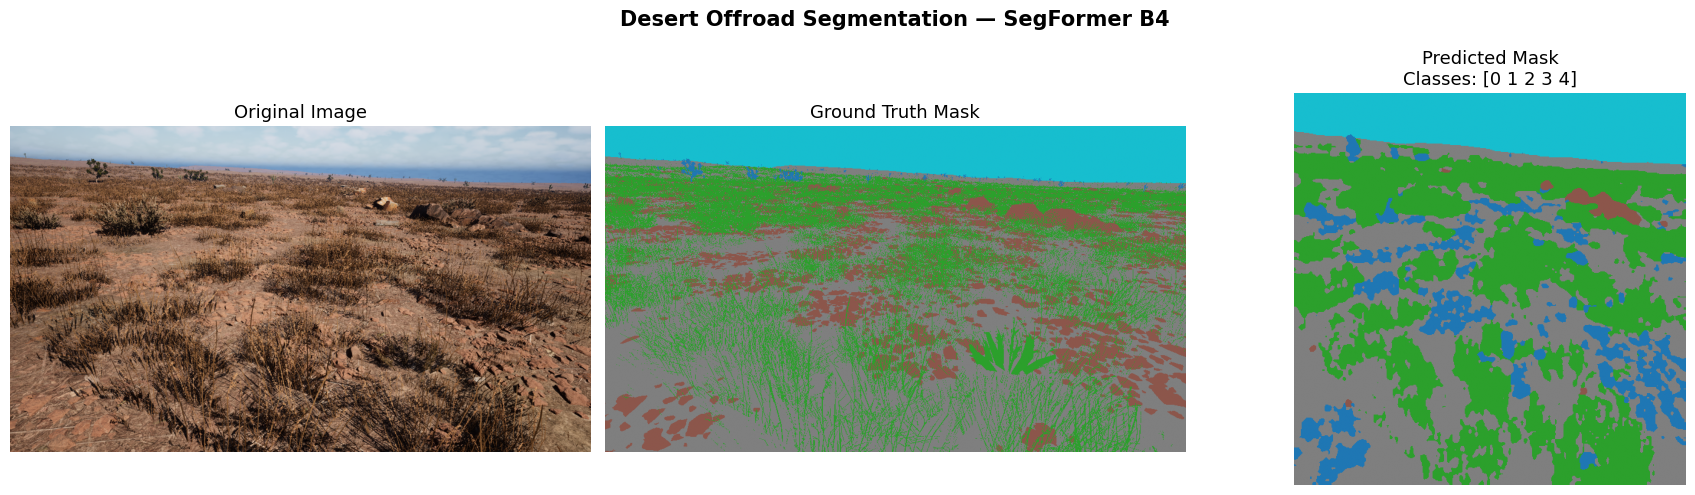

In [3]:
import os, cv2, torch, numpy as np
import torch.nn.functional as F
import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mapping = {0:0, 1:1, 3:2, 27:3, 39:4}
NUM_CLASSES = 5

class DesertDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.images    = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image    = cv2.cvtColor(cv2.imread(os.path.join(self.image_dir, self.images[idx])), cv2.COLOR_BGR2RGB)
        raw_mask = cv2.imread(os.path.join(self.mask_dir, self.images[idx]), cv2.IMREAD_GRAYSCALE)
        mask = np.zeros(raw_mask.shape, dtype=np.uint8)
        for k, v in mapping.items(): mask[raw_mask == k] = v
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        return torch.tensor(image).permute(2,0,1).float()/255., torch.tensor(mask).long()

transform    = A.Compose([A.Resize(512,512)])
train_dataset = DesertDataset(
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/train/Color_Images",
    "/kaggle/input/datasets/mohith2045/desert-segmentation/Offroad_Segmentation_Training_Dataset/train/Segmentation",
    transform=transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

img, msk = train_dataset[0]
print("✅ Mask classes:", torch.unique(msk).tolist())

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b4-finetuned-ade-512-512",
    num_labels=NUM_CLASSES, ignore_mismatched_sizes=True).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)
ce_loss   = torch.nn.CrossEntropyLoss()
scaler    = torch.cuda.amp.GradScaler()

for epoch in range(5):
    model.train(); total_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        with torch.amp.autocast("cuda"):
            out  = F.interpolate(model(pixel_values=images).logits, size=(512,512), mode="bilinear", align_corners=False)
            loss = ce_loss(out, masks)
        optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {total_loss/len(train_loader):.4f}")

print("✅ Training done! Running inference...")

# ── Inference & display ───────────────────────────────────────
model.eval()
img_path  = "/kaggle/input/datasets/mohith2045/desert-test/Offroad_Segmentation_testImages/Color_Images/0000060.png"
mask_path = "/kaggle/input/datasets/mohith2045/desert-test/Offroad_Segmentation_testImages/Segmentation/0000060.png"

image    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
raw_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
gt_mask  = np.zeros(raw_mask.shape, dtype=np.uint8)
for k, v in mapping.items(): gt_mask[raw_mask == k] = v

tensor = torch.tensor(cv2.resize(image,(512,512))).permute(2,0,1).float()/255.
with torch.no_grad():
    out  = model(pixel_values=tensor.unsqueeze(0).to(device)).logits
    out  = F.interpolate(out, size=(512,512), mode="bilinear", align_corners=False)
    pred = out.argmax(1).squeeze().cpu().numpy()

print("Predicted classes:", np.unique(pred))

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].imshow(image);                                   axes[0].set_title("Original Image",    fontsize=13); axes[0].axis("off")
axes[1].imshow(gt_mask, cmap="tab10", vmin=0, vmax=4);  axes[1].set_title("Ground Truth Mask", fontsize=13); axes[1].axis("off")
axes[2].imshow(pred,    cmap="tab10", vmin=0, vmax=4);  axes[2].set_title(f"Predicted Mask\nClasses: {np.unique(pred)}", fontsize=13); axes[2].axis("off")
plt.suptitle("Desert Offroad Segmentation — SegFormer B4", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("final_result.png", dpi=150, bbox_inches="tight"); plt.show()